In [ ]:

import argparse
import os
import sys
from pathlib import Path

import torch
from transformers import AutoTokenizer

# crop_embed and DNABERT2_modules live in variant_cache/
from DNABERT2_modules import load_dnabert2

In [3]:
MODEL_PATH = "zhihan1996/DNABERT-2-117M"

print(f"\nLoading DNABERT-2 from {MODEL_PATH} …")
_local = os.path.isdir(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True, use_fast=False, local_files_only=_local)
model, _  = load_dnabert2(
    repo_id=MODEL_PATH,
    add_pooling_layer=False,
    config_overrides={"pad_token_id": tokenizer.pad_token_id},
)


Loading DNABERT-2 from zhihan1996/DNABERT-2-117M …


In [7]:
dna = "ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC"
dna2 = "GTAGCATCGGATCTATCTATCGACACTTGGTTATCGA"
inputs = tokenizer([dna, dna2], return_tensors="pt", padding=True, truncation=True, max_length=512)
print(inputs)

{'input_ids': tensor([[   1,    5,  194,   32,  757, 1239, 2092,  294,   24,  359,   88,   93,
           32,   75,   77,   19,    2],
        [   1, 1130,  757, 1239, 2092,  294,   24,  359,    2,    3,    3,    3,
            3,    3,    3,    3,    3]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])}


In [8]:
outputs = model(**inputs)
hidden  = outputs.last_hidden_state   

In [ ]:
pool_mask = inputs["attention_mask"].unsqueeze(-1).float()   # (B, T, 1)
vecs = (hidden * pool_mask).sum(1) / pool_mask.sum(1).clamp(min=1)
vecs = vecs.cpu()

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])


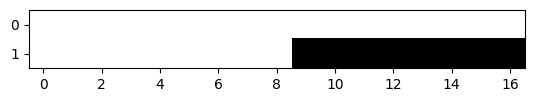

In [14]:
import matplotlib.pyplot as plt
plt.imshow(pool_mask.cpu().squeeze(-1), cmap="gray", vmin=0, vmax=1)
print(pool_mask.cpu().squeeze(-1))